# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2381 Соколов Сергей и Тищенко Артем. Вариант №22

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

Статистический ряд - последовательность элементов выборки, расположенных в порядке их получения.

Ранжированный ряд - последовательность элементов выборки, расположенных в порядке возрастания их значений. Номер элемента ранжированного ряда в последовательности называется рангом.

Вариационный ряд получается из ранжированного в результате объединения одинаковых элементов. Элементы вариационнго ряда называются вариантами.

При большом количестве вариант можно построить интервальный ряд, путем разделения на интервалы. Количество интервалов рассчитывается по формуле Стерджесса:

$$k = 1 + 3.31 \cdot \lg(N)$$

С округлением до целого.

Ширина интервала вычисляется по формуле:

$$h = \frac{x_{max} - x_{min}}{k}$$

Границы интервалов определяются как:

$\left[x_{min} + (i - 1) \cdot h; x_{min} + i \cdot h \right), i = 1, 2,\dots, k -1$,
где $i -$ номер интервала.

Последний интервал определяется как:
$\left[x_{min} + (k - 1) \cdot h; x_{min} + ik \cdot h \right]$

Для каждого интервала считают частоту попаданий значений вариант в интервалы и вычисляют середину интервала.

Полигон частот $-$ ломаная, соединяющую точки, соответствующие серединам интервалов и частотам этих интервалов.

Гистограмма частот $-$ гистограмма, где для каждого интервала площадь соответствующего прямоугльника равна частоте.

Эмпирическая функция распределения - функция $F^*(x)$, определяющая частоту события $X < x$. График представляет собой лестничный график, длина каждой ступеньки равна длине соотетвствующего интервала, а высота $-$ отношению накопленной частоты до середины этого интервала к объему выборки.


## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы


Подключение библиотек и загрузка выборки

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N = 112
df = pd.read_csv('brigade22.csv')
df.head()

,nu,E
0,434,108.7
1,463,129.1
2,444,130.0
3,408,110.0
4,478,136.6


Преобразование двумерной выборки в одномерную

In [3]:
df = df.drop('E', axis=1)
df.head()

,nu
0,434
1,463
2,444
3,408
4,478


### Задание 1
Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде табл. 1. Результаты содержательно проинтерпретировать.

#### Преобразование выборки в ранжированный ряд

In [4]:
df1 = df.sort_values('nu', ignore_index=True)
df1

,nu
0,320
1,331
2,351
3,362
4,362
...,...
107,560
108,566
109,572
110,576


#### Преобразование ранжированного ряда в вариационный ряд

In [5]:
df2 = df1.groupby('nu').first()
df2['count'] = df1['nu'].value_counts()
df2['frequency'] = df2['count'] / N
df2.reset_index(inplace=True)
df2['nu']

,nu
0,320
1,331
2,351
3,362
4,371
...,...
80,560
81,566
82,572
83,576


Всего в выборке оказалось 85 вариант

#### Построенние интервального ряда

Рассчета колличества интервалов $k$

In [6]:
k = int(np.round(1 + 3.31 * np.log10(N)))
k

8

Рассчет ширины интервала $h$

In [7]:
h = (df2['nu'].max() - df2['nu'].min()) / k
h

33.875

Построенние ряда

In [8]:
df3 = pd.DataFrame(columns=['[xi; xi+1)', 'mid_xi', 'mi', 'rel_mi', 's_mi', 's_rel_mi'])

for i in range(k):
  xmin = df2['nu'].min() + i * h
  xmax = df2['nu'].min() + (i + 1) * h
  xmid = (xmin + xmax) / 2

  mi = df2[(df2['nu'].between(
      xmin,
      xmax,
      inclusive='left' if i != k - 1 else 'both')
  )]['count'].sum()

  rel_mi = mi / N

  df3.loc[i] = [
      f'[{xmin}; {xmax})' if i != k - 1 else f'[{xmin}; {xmax}]',
      xmid,
      mi,
      rel_mi,
      df3.loc[i - 1, 's_mi'] + mi if i > 0 else mi,
      df3.loc[i - 1, 's_rel_mi'] + rel_mi if i > 0 else rel_mi
  ]

df3


,[xi; xi+1),mid_xi,mi,rel_mi,s_mi,s_rel_mi
0,[320.0; 353.875),336.9375,3,0.026786,3,0.026786
1,[353.875; 387.75),370.8125,8,0.071429,11,0.098214
2,[387.75; 421.625),404.6875,18,0.160714,29,0.258929
3,[421.625; 455.5),438.5625,28,0.250000,57,0.508929
4,[455.5; 489.375),472.4375,24,0.214286,81,0.723214
5,[489.375; 523.25),506.3125,18,0.160714,99,0.883929
6,[523.25; 557.125),540.1875,8,0.071429,107,0.955357
7,[557.125; 591.0],574.0625,5,0.044643,112,1.000000


In [9]:
df3.to_excel('df3.xlsx')

In [10]:
print(df3['mi'].sum())
print(df3['rel_mi'].sum())

112
1.0


Получим таблицу для интервального ряда:

|     |  $[x_i; x_{i+1})$ | $\tilde{x}_i$ | $m_i$ | $\tilde{m}_i$ | $m_i^{нак}$ | $\tilde{m}_i^{нак}$ |
|-----|:-----------------:|:-------------:|:---:|:-----------:|:-----------:|:-------------------:|
|  1  | [320.0; 353.875)  | 336.9375      | 3   | 0.026786    | 3           | 0.026786            |
|  2  | [353.875; 387.75) | 370.8125      | 8   | 0.071429    | 11          | 0.098214            |
|  3  | [387.75; 421.625) | 404.6875      | 18  | 0.160714    | 29          | 0.258929            |
|  4  | [421.625; 455.5)  | 438.5625      | 28  | 0.25        | 57          | 0.508929            |
|  5  | [455.5; 489.375)  | 472.4375      | 24  | 0.214286    | 81          | 0.723214            |
|  6  | [489.375; 523.25) | 506.3125      | 18  | 0.160714    | 99          | 0.883929            |
|  7  | [523.25; 557.125) | 540.1875      | 8   | 0.071429    | 107         | 0.955357            |
|  8  | [557.125; 591.0]  | 574.0625      | 5   | 0.044643    | 112         | 1                   |
|  |                   |         $\sum$      | 112 | 1           |       -      |          -           |

Из таблицы видно, что наибольшая частота достигается в 4-м интервале, при этом при отдалении от 4-го интервала частота попаданий в интервалы монотонно уменьшается.

Для 8-го интервала значения накопленной частоты равно сумме частот всех интерваллов.

### Задание 2
Для абсолютных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы.

#### Построенние полигона

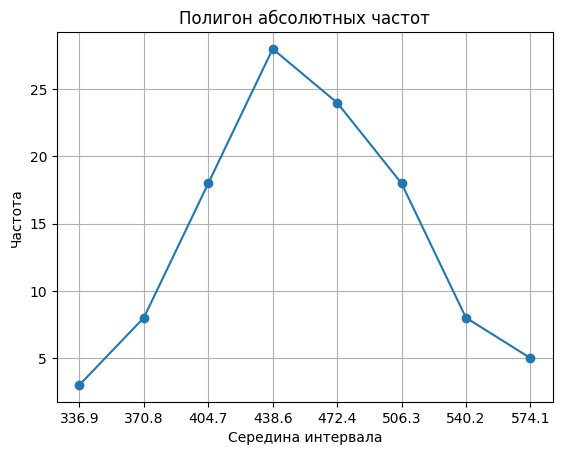

In [11]:
plt.plot(df3['mid_xi'], df3['mi'], 'o-')
plt.xticks(df3['mid_xi'])
plt.title('Полигон абсолютных частот')
plt.xlabel('Середина интервала')
plt.ylabel('Частота')
plt.grid()
plt.show()

#### Построение гистограммы

In [12]:
heights = df3['mi'] / h
heights

,mi
0,0.088561
1,0.236162
2,0.531365
3,0.826568
4,0.708487
5,0.531365
6,0.236162
7,0.147601


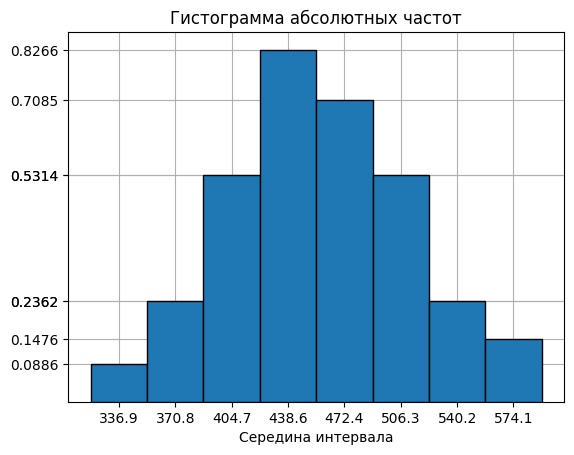

In [13]:
plt.bar(df3['mid_xi'], heights, width=h, edgecolor='black', zorder=3)
plt.title('Гистограмма абсолютных частот')
plt.xlabel('Середина интервала')
plt.xticks(df3['mid_xi'])
plt.yticks(heights)
plt.grid(zorder=0)
plt.show()

#### Построение эмпирической функции

In [14]:
f_star = df2['count'].cumsum()
f_star

,count
0,1
1,2
2,3
3,5
4,6
...,...
80,108
81,109
82,110
83,111


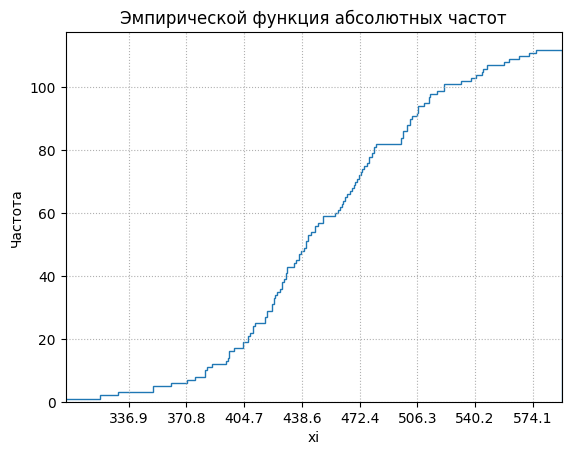

In [15]:
edges = [0]
edges.extend(df2['nu'].to_list())
plt.xlim(300, df2['nu'].max())
plt.grid(ls='dotted')
plt.title('Эмпирической функция абсолютных частот')
plt.xticks(df3['mid_xi'])
plt.xlabel('xi')
plt.ylabel('Частота')
plt.stairs(f_star, edges)
plt.show()

Полигон и гистограмма показывают, что для интервала с серединой 438.5625 частота наибольшая. Отдаляясь частота уменьшается, при этом при движении влево частота уменьшается сильнее чем вправо. На эмпирической функции это наблюдается как более медленный рост функции в начале

### Задание 3
Для относительных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы.

#### Построенние полигона

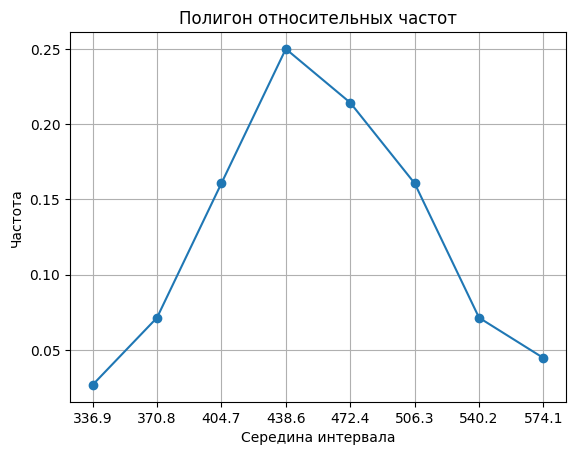

In [16]:
plt.plot(df3['mid_xi'], df3['rel_mi'], 'o-')
plt.xticks(df3['mid_xi'])
plt.title('Полигон относительных частот')
plt.xlabel('Середина интервала')
plt.ylabel('Частота')
plt.grid()
plt.show()

#### Построение гистограммы

In [17]:
heights = df3['rel_mi'] / h
heights

,rel_mi
0,0.000791
1,0.002109
2,0.004744
3,0.007380
4,0.006326
5,0.004744
6,0.002109
7,0.001318


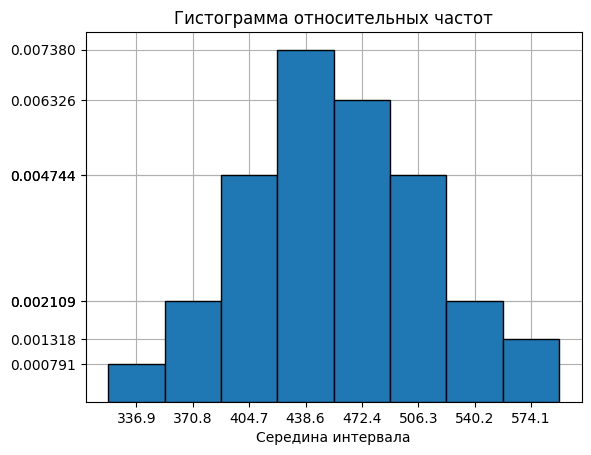

In [18]:
plt.bar(df3['mid_xi'], heights, width=h, edgecolor='black', zorder=3)
plt.title('Гистограмма относительных частот')
plt.xlabel('Середина интервала')
plt.xticks(df3['mid_xi'])
plt.yticks(heights,)
plt.grid(zorder=0)
plt.show()

#### Построение эмпирической функции

In [19]:
f_star = df2['frequency'].cumsum()
f_star

,frequency
0,0.008929
1,0.017857
2,0.026786
3,0.044643
4,0.053571
...,...
80,0.964286
81,0.973214
82,0.982143
83,0.991071


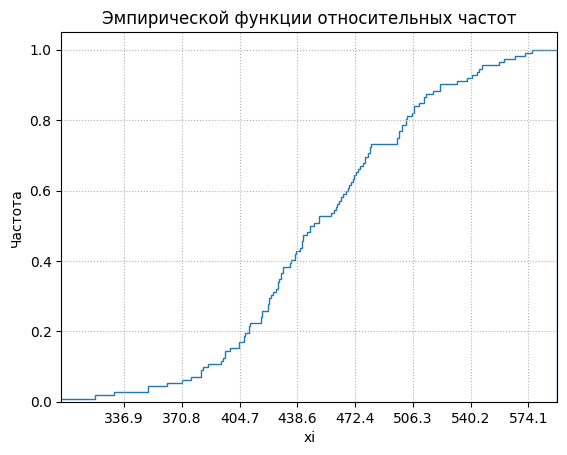

In [20]:
edges = [0]
edges.extend(df2['nu'].to_list())
plt.xlim(300, df2['nu'].max())
plt.grid(ls='dotted')
plt.title('Эмпирической функции относительных частот')
plt.xticks(df3['mid_xi'])
plt.xlabel('xi')
plt.ylabel('Частота')
plt.stairs(f_star, edges)
plt.show()

Все графики полученные для относительных частот аналогичны графикам для абсолютных частот.

На графике полинома видно, что на интервале с серединой 438.5625 находится четверть всех измерений.

Из графика эмпирической функции видно, что перед 438.5625 находится примерно 40% элементов выборки.

## Выводы

 Были подготовлены выборочные данные к статистическому анализу: получены ранжированный, вариационный, интервальный ряды. Были построены полигоны, гистограммы и графики эмпирических функции абсолютных и относительных частот. Большинство элементов выборки оказалась в интервале $[421.625; 455.5)$ и при отдалении от него частота уменьшалась.